<a href="https://colab.research.google.com/github/RamanSambharia/Python-Assignment/blob/main/Fundamental.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
print('Libraries loaded.')

Libraries loaded.


In [2]:
from io import StringIO
import requests

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data'
response = requests.get(url)
headers = [
    'symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
    'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
    'wheel-base', 'length', 'width', 'height', 'curb-weight',
    'engine-type', 'num-of-cylinders', 'engine-size', 'fuel-system',
    'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm',
    'city-mpg', 'highway-mpg', 'price'
]
df = pd.read_csv(StringIO(response.text), names=headers)
print(f'Shape: {df.shape}')
df.head(10)

Shape: (205, 26)


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,?


In [3]:
df.replace('?', np.nan, inplace=True)

for col in ['price', 'horsepower', 'normalized-losses', 'bore', 'stroke', 'peak-rpm']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.dtypes)

symboling              int64
normalized-losses    float64
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
dtype: object


In [4]:
numeric_df = df.select_dtypes(include=[np.number])

print('--- Mean ---')
print(numeric_df.mean().round(2))
print('\n--- Median ---')
print(numeric_df.median().round(2))
print('\n--- Standard Deviation ---')
print(numeric_df.std().round(2))

--- Mean ---
symboling                0.83
normalized-losses      122.00
wheel-base              98.76
length                 174.05
width                   65.91
height                  53.72
curb-weight           2555.57
engine-size            126.91
bore                     3.33
stroke                   3.26
compression-ratio       10.14
horsepower             104.26
peak-rpm              5125.37
city-mpg                25.22
highway-mpg             30.75
price                13207.13
dtype: float64

--- Median ---
symboling                1.00
normalized-losses      115.00
wheel-base              97.00
length                 173.20
width                   65.50
height                  54.10
curb-weight           2414.00
engine-size            120.00
bore                     3.31
stroke                   3.29
compression-ratio        9.00
horsepower              95.00
peak-rpm              5200.00
city-mpg                24.00
highway-mpg             30.00
price                10295

In [5]:
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f'{col}: {df[col].nunique()} unique -> {df[col].unique()}')
    print()

make: 22 unique -> ['alfa-romero' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'mazda' 'mercedes-benz' 'mercury' 'mitsubishi' 'nissan' 'peugot'
 'plymouth' 'porsche' 'renault' 'saab' 'subaru' 'toyota' 'volkswagen'
 'volvo']

fuel-type: 2 unique -> ['gas' 'diesel']

aspiration: 2 unique -> ['std' 'turbo']

num-of-doors: 2 unique -> ['two' 'four' nan]

body-style: 5 unique -> ['convertible' 'hatchback' 'sedan' 'wagon' 'hardtop']

drive-wheels: 3 unique -> ['rwd' 'fwd' '4wd']

engine-location: 2 unique -> ['front' 'rear']

engine-type: 7 unique -> ['dohc' 'ohcv' 'ohc' 'l' 'rotor' 'ohcf' 'dohcv']

num-of-cylinders: 7 unique -> ['four' 'six' 'five' 'three' 'twelve' 'two' 'eight']

fuel-system: 8 unique -> ['mpfi' '2bbl' 'mfi' '1bbl' 'spfi' '4bbl' 'idi' 'spdi']



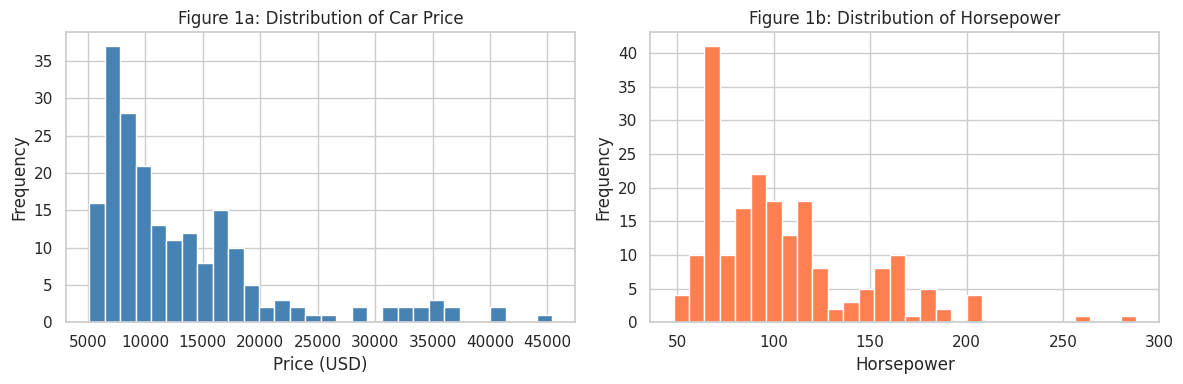

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['price'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Figure 1a: Distribution of Car Price')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['horsepower'].dropna(), bins=30, color='coral', edgecolor='white')
axes[1].set_title('Figure 1b: Distribution of Horsepower')
axes[1].set_xlabel('Horsepower')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('fig1_histograms.png', bbox_inches='tight')
plt.show()

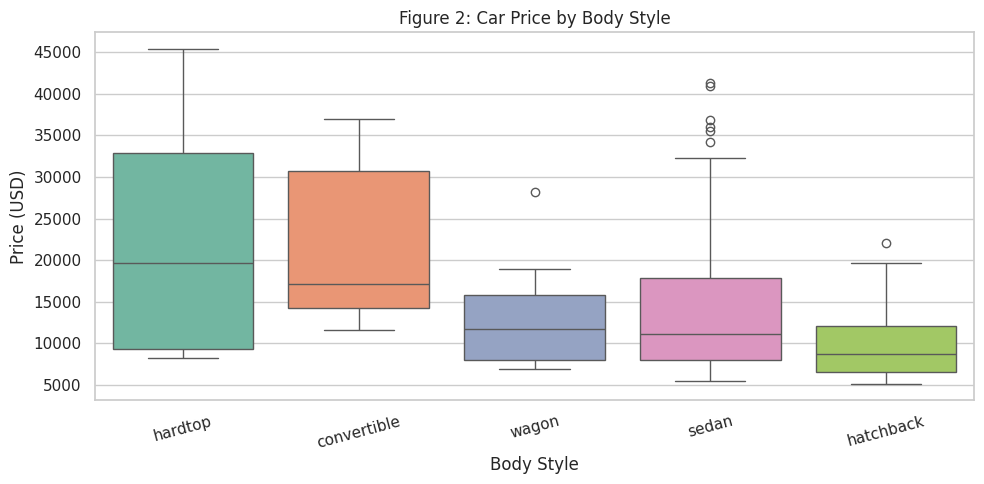

In [7]:
plt.figure(figsize=(10, 5))
order = df.groupby('body-style')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='body-style', y='price', order=order, palette='Set2')
plt.title('Figure 2: Car Price by Body Style')
plt.xlabel('Body Style')
plt.ylabel('Price (USD)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('fig2_boxplot_bodystyle.png', bbox_inches='tight')
plt.show()

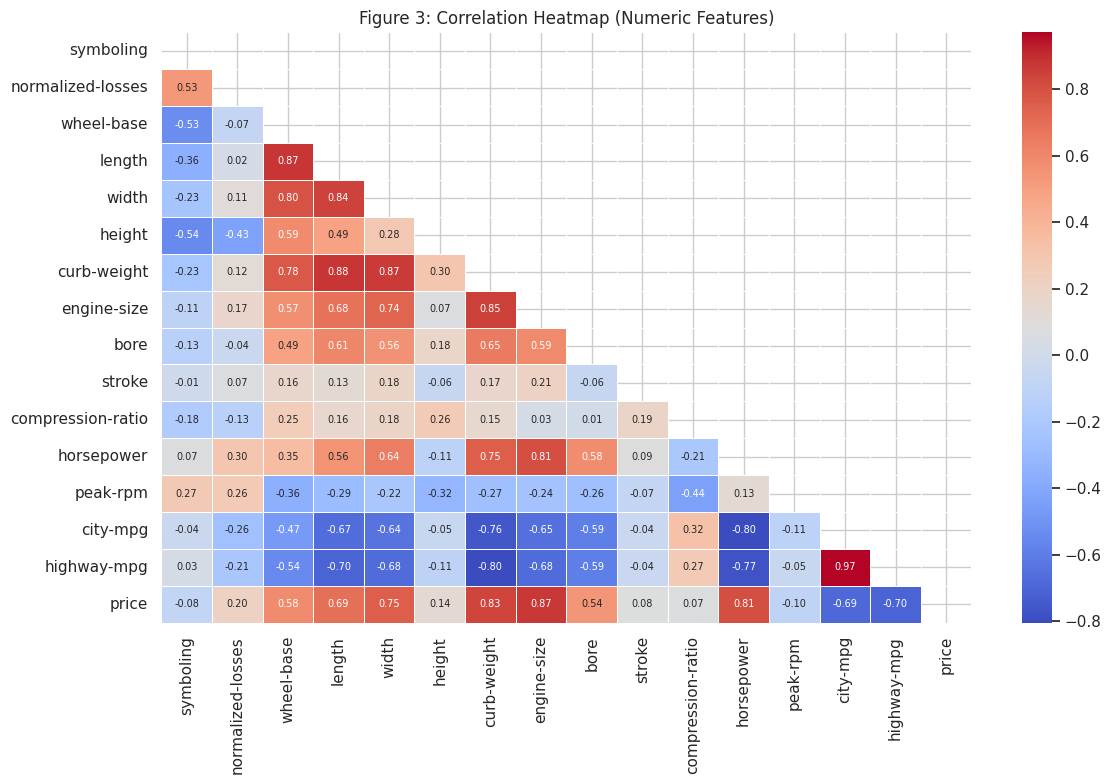

In [8]:
plt.figure(figsize=(12, 8))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, annot_kws={'size': 7})
plt.title('Figure 3: Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.savefig('fig3_correlation_heatmap.png', bbox_inches='tight')
plt.show()

TASK 2: Data Preprocessing & Feature Engineering

In [9]:
missing = df.isnull().sum()
print('Columns with missing values:')
print(missing[missing > 0])

Columns with missing values:
normalized-losses    41
num-of-doors          2
bore                  4
stroke                4
horsepower            2
peak-rpm              2
price                 4
dtype: int64


In [10]:
numeric_missing = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm', 'price']
for col in numeric_missing:
    mean_val = df[col].mean()
    df[col].fillna(mean_val, inplace=True)
    print(f'[MEAN] {col} filled with {mean_val:.2f}')

df['num-of-doors'].fillna(df['num-of-doors'].mode()[0], inplace=True)
print('[MODE] num-of-doors filled with:', df['num-of-doors'].mode()[0])

print(f'\nRemaining missing: {df.isnull().sum().sum()}')

[MEAN] normalized-losses filled with 122.00
[MEAN] bore filled with 3.33
[MEAN] stroke filled with 3.26
[MEAN] horsepower filled with 104.26
[MEAN] peak-rpm filled with 5125.37
[MEAN] price filled with 13207.13
[MODE] num-of-doors filled with: four

Remaining missing: 0


In [11]:
df['price'] = df['price'].astype(float)
df['horsepower'] = df['horsepower'].astype(float)
print('price dtype:', df['price'].dtype)
print('horsepower dtype:', df['horsepower'].dtype)

price dtype: float64
horsepower dtype: float64


In [12]:
df['city-L/100km'] = 235 / df['city-mpg']
print('New feature created:')
print(df[['city-mpg', 'city-L/100km']].head())

New feature created:
   city-mpg  city-L/100km
0        21     11.190476
1        21     11.190476
2        19     12.368421
3        24      9.791667
4        18     13.055556


Bin boundaries: [ 48. 128. 208. 288.]
horsepower-binned
Low       163
Medium     40
High        2
Name: count, dtype: int64


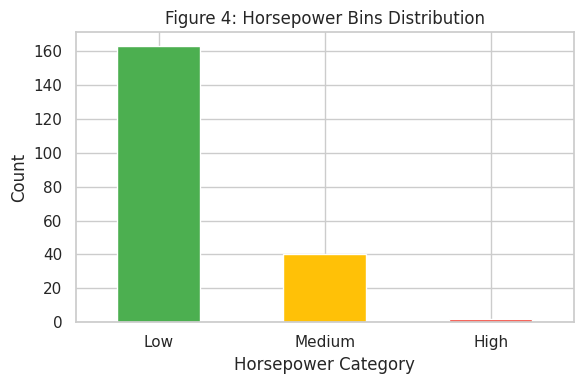

In [13]:
bins = np.linspace(df['horsepower'].min(), df['horsepower'].max(), 4)
group_names = ['Low', 'Medium', 'High']
df['horsepower-binned'] = pd.cut(df['horsepower'], bins=bins,
                                  labels=group_names, include_lowest=True)
print('Bin boundaries:', bins.round(1))
print(df['horsepower-binned'].value_counts())

plt.figure(figsize=(6, 4))
df['horsepower-binned'].value_counts().sort_index().plot(
    kind='bar', color=['#4CAF50','#FFC107','#F44336'], edgecolor='white')
plt.title('Figure 4: Horsepower Bins Distribution')
plt.xlabel('Horsepower Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('fig4_horsepower_bins.png', bbox_inches='tight')
plt.show()

In [14]:
scaler = MinMaxScaler()
df['engine-size-norm'] = scaler.fit_transform(df[['engine-size']])
print('engine-size normalised:')
print(df[['engine-size', 'engine-size-norm']].describe().round(3))

engine-size normalised:
       engine-size  engine-size-norm
count      205.000           205.000
mean       126.907             0.249
std         41.643             0.157
min         61.000             0.000
25%         97.000             0.136
50%        120.000             0.223
75%        141.000             0.302
max        326.000             1.000


TASK 3: Regression Models

In [15]:
feature_cols = ['engine-size', 'horsepower', 'curb-weight', 'width',
                'highway-mpg', 'city-L/100km', 'bore', 'wheel-base']
target_col = 'price'

model_df = df[feature_cols + [target_col]].dropna()
X = model_df[feature_cols]
y = model_df[target_col]

print(f'Modelling dataset: {model_df.shape[0]} rows, {len(feature_cols)} features')

Modelling dataset: 205 rows, 8 features


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

r2_lr  = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)

print('=== Linear Regression — 80/20 ===')
print(f'R²   : {r2_lr:.4f}')
print(f'MAE  : ${mae_lr:,.2f}')
print(f'MSE  : {mse_lr:,.2f}')
print(f'RMSE : ${np.sqrt(mse_lr):,.2f}')

=== Linear Regression — 80/20 ===
R²   : 0.7945
MAE  : $2,706.69
MSE  : 16,026,530.41
RMSE : $4,003.31


In [17]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

r2_rf  = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)

print('=== Random Forest — 80/20 ===')
print(f'R²   : {r2_rf:.4f}')
print(f'MAE  : ${mae_rf:,.2f}')
print(f'MSE  : {mse_rf:,.2f}')
print(f'RMSE : ${np.sqrt(mse_rf):,.2f}')

=== Random Forest — 80/20 ===
R²   : 0.9303
MAE  : $1,487.91
MSE  : 5,436,183.62
RMSE : $2,331.56


In [18]:
X_train70, X_test30, y_train70, y_test30 = train_test_split(
    X, y, test_size=0.3, random_state=42)

lr70 = LinearRegression()
lr70.fit(X_train70, y_train70)
y_pred_lr70 = lr70.predict(X_test30)

rf70 = RandomForestRegressor(n_estimators=100, random_state=42)
rf70.fit(X_train70, y_train70)
y_pred_rf70 = rf70.predict(X_test30)

print(f'{"Model":<25} {"Split":<8} {"R²":>8} {"MAE":>12}')
print('-' * 56)
print(f'{"Linear Regression":<25} {"80/20":<8} {r2_lr:>8.4f} {mae_lr:>12,.0f}')
print(f'{"Linear Regression":<25} {"70/30":<8} {r2_score(y_test30, y_pred_lr70):>8.4f} {mean_absolute_error(y_test30, y_pred_lr70):>12,.0f}')
print(f'{"Random Forest":<25} {"80/20":<8} {r2_rf:>8.4f} {mae_rf:>12,.0f}')
print(f'{"Random Forest":<25} {"70/30":<8} {r2_score(y_test30, y_pred_rf70):>8.4f} {mean_absolute_error(y_test30, y_pred_rf70):>12,.0f}')

Model                     Split          R²          MAE
--------------------------------------------------------
Linear Regression         80/20      0.7945        2,707
Linear Regression         70/30      0.7524        2,673
Random Forest             80/20      0.9303        1,488
Random Forest             70/30      0.8933        1,667


TASK 4: Classification Model

In [19]:
df_cls = df[feature_cols + ['price']].dropna().copy()
df_cls['price-category'] = pd.qcut(df_cls['price'], 3, labels=['Low', 'Medium', 'High'])

print('Price category distribution:')
print(df_cls['price-category'].value_counts())

le = LabelEncoder()
y_cls = le.fit_transform(df_cls['price-category'])
X_cls = df_cls[feature_cols]

sc = MinMaxScaler()
X_cls_scaled = sc.fit_transform(X_cls)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_cls_scaled, y_cls, test_size=0.2, random_state=42)

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_tr, y_tr)
y_pred_cls = log_model.predict(X_te)

print(f'\nAccuracy: {accuracy_score(y_te, y_pred_cls):.4f}')

Price category distribution:
price-category
High      69
Low       68
Medium    68
Name: count, dtype: int64

Accuracy: 0.7073


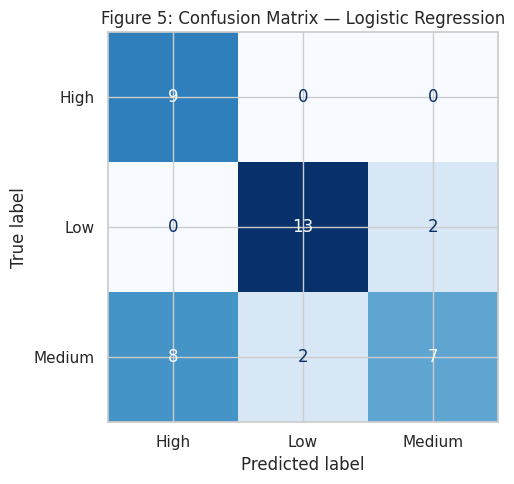

In [20]:
cm = confusion_matrix(y_te, y_pred_cls)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Figure 5: Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.savefig('fig5_confusion_matrix.png', bbox_inches='tight')
plt.show()

TASK 5: Model Evaluation & Visualisation

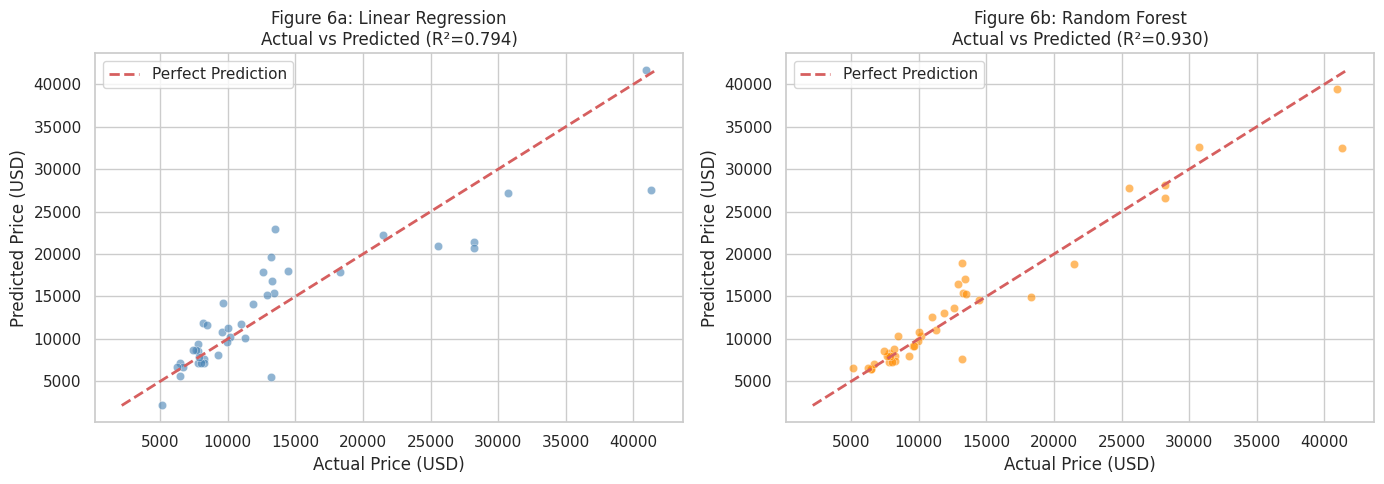

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

min_val = min(y_test.min(), y_pred_lr.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_lr.max(), y_pred_rf.max())

axes[0].scatter(y_test, y_pred_lr, alpha=0.6, color='steelblue', edgecolors='white', lw=0.4)
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_title(f'Figure 6a: Linear Regression\nActual vs Predicted (R²={r2_lr:.3f})')
axes[0].set_xlabel('Actual Price (USD)')
axes[0].set_ylabel('Predicted Price (USD)')
axes[0].legend()

axes[1].scatter(y_test, y_pred_rf, alpha=0.6, color='darkorange', edgecolors='white', lw=0.4)
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[1].set_title(f'Figure 6b: Random Forest\nActual vs Predicted (R²={r2_rf:.3f})')
axes[1].set_xlabel('Actual Price (USD)')
axes[1].set_ylabel('Predicted Price (USD)')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig6_actual_vs_predicted.png', bbox_inches='tight')
plt.show()

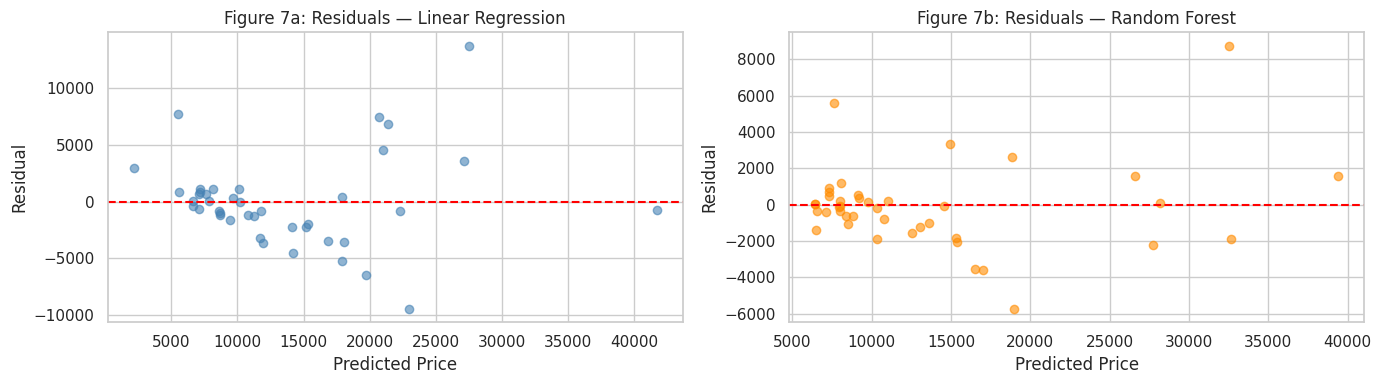

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

residuals_lr = y_test - y_pred_lr
residuals_rf = y_test - y_pred_rf

axes[0].scatter(y_pred_lr, residuals_lr, alpha=0.6, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Figure 7a: Residuals — Linear Regression')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residual')

axes[1].scatter(y_pred_rf, residuals_rf, alpha=0.6, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Figure 7b: Residuals — Random Forest')
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.savefig('fig7_residuals.png', bbox_inches='tight')
plt.show()

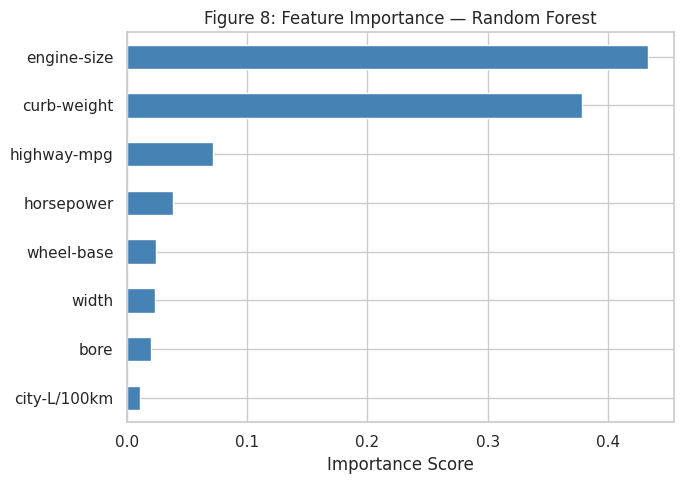

In [23]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(7, 5))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Figure 8: Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('fig8_feature_importance.png', bbox_inches='tight')
plt.show()